## 1. Setup & Environment

In [ ]:
!pip install torch torchvision timm transformers -q
!pip install scikit-learn matplotlib seaborn tqdm Pillow -q
!pip install torchattacks -q
!pip install grad-cam -q

import torch
import torch.nn as nn
import os
import random
import warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
warnings.filterwarnings('ignore')


SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Device: {device}')
if device.type == 'cuda':
    print(f'🚀 GPU: {torch.cuda.get_device_name(0)}')
    print(f'💾 GPU Memory: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.7/178.7 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.2/144.2 kB 15.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.25.1 which is incompatible.
pysal 25.7 requires requests>=2.27, but you have requests 2.25.1 which is incompatible.
tweepy 4.16.0 requires requests<3,>=2.27.0, but you have requests 2.25.1 which is incompatible.
bigframes 2.42.0 requires requests>=2.27.1, but you have request

## 2. Dataset Download (Kaggle Chest X-Ray Pneumonia)

In [ ]:
import os
import zipfile
from google.colab import files
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from sklearn.model_selection import train_test_split
from collections import Counter
from PIL import Image


if not os.path.exists('/root/.kaggle/kaggle.json'):
    print("📥 Please upload your 'kaggle.json' credential file:")
    uploaded = files.upload()

    !mkdir -p ~/.kaggle
    !mv kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json
    print("✅ Kaggle API Credentials Configured Successfully!")


print("🚀 Downloading Chest X-Ray Dataset from Kaggle...")
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia


print("📦 Unzipping dataset files...")
with zipfile.ZipFile('chest-xray-pneumonia.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/kaggle_chest_xray')

print("✅ Dataset extraction complete!")


📥 Please upload your 'kaggle.json' credential file:


Saving kaggle (1).json to kaggle (1).json
mv: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
✅ Kaggle API Credentials Configured Successfully!
🚀 Downloading Chest X-Ray Dataset from Kaggle...
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:26<00:00, 94.0MB/s]

📦 Unzipping dataset files...
✅ Dataset extraction complete!


In [ ]:
DATASET_PATH = '/content/kaggle_chest_xray/chest_xray'

CLASSES = ['normal', 'pneumonia']
EXTENSIONS = ('.jpg', '.jpeg', '.png')

image_paths, labels = [], []


for root, dirs, files in os.walk(DATASET_PATH):

    dirs[:] = [d for d in dirs if not d.startswith('__MACOSX')]
    for f in files:

        if f.startswith('._') or '__MACOSX' in root:
            continue

        if f.lower().endswith(EXTENSIONS):
            path = os.path.join(root, f)
            path_lower = path.lower()

            cls_found = next((c for c in CLASSES if c in path_lower), None)
            if cls_found:
                image_paths.append(path)
                labels.append(CLASSES.index(cls_found))

print(f'\n✅ Total images processed from Kaggle: {len(image_paths)}')
print(f'📊 Unified Binary Class Distribution:')
for i, cls_name in enumerate(CLASSES):
    print(f'   {cls_name.upper()}: {labels.count(i)} samples')



✅ Total images processed from Kaggle: 11712
📊 Unified Binary Class Distribution:
   NORMAL: 3166 samples
   PNEUMONIA: 8546 samples


In [ ]:
import pandas as pd

df = pd.DataFrame({'path': image_paths, 'label': labels})
df.head(100)


,path,label
0,/content/kaggle_chest_xray/chest_xray/test/NOR...,0
1,/content/kaggle_chest_xray/chest_xray/test/NOR...,0
2,/content/kaggle_chest_xray/chest_xray/test/NOR...,0
3,/content/kaggle_chest_xray/chest_xray/test/NOR...,0
4,/content/kaggle_chest_xray/chest_xray/test/NOR...,0
...,...,...
95,/content/kaggle_chest_xray/chest_xray/test/NOR...,0
96,/content/kaggle_chest_xray/chest_xray/test/NOR...,0
97,/content/kaggle_chest_xray/chest_xray/test/NOR...,0
98,/content/kaggle_chest_xray/chest_xray/test/NOR...,0


## 3. Stratified Splits & Datasets

In [ ]:
class PneumoniaDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

indices = list(range(len(image_paths)))
train_idx, temp_idx = train_test_split(indices, test_size=0.30, random_state=SEED, stratify=labels)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.50, random_state=SEED, stratify=[labels[i] for i in temp_idx])

print(f'\n✅ Scientific Partitioning:')
print(f'   ↳ Training Pool   : {len(train_idx)} images')
print(f'   ↳ Validation Pool : {len(val_idx)} images')
print(f'   ↳ Evaluation Pool : {len(test_idx)} images')



✅ Scientific Partitioning:
   ↳ Training Pool   : 8198 images
   ↳ Validation Pool : 1757 images
   ↳ Evaluation Pool : 1757 images


## 4. Transforms & DataLoaders

Identical augmentation pipeline for every backbone — this keeps comparisons fair, since all three models see the exact same training distribution and the exact same val/test images.

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.15)),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

def make_subset(idx_list, transform):
    return PneumoniaDataset(
        [image_paths[i] for i in idx_list],
        [labels[i] for i in idx_list],
        transform
    )

train_labels = [labels[i] for i in train_idx]
class_counts = Counter(train_labels)
class_weights = {cls: 1.0/count for cls, count in class_counts.items()}
sample_weights = [class_weights[l] for l in train_labels]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

train_dataset = make_subset(train_idx, train_transform)
val_dataset = make_subset(val_idx, val_transform)
test_dataset = make_subset(test_idx, val_transform)


train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler, num_workers=2, pin_memory=True, persistent_workers=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True, persistent_workers=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True, persistent_workers=True)

print('✅ DataLoaders ready!')
print(f'   Train batches : {len(train_loader)}')
print(f'   Val batches   : {len(val_loader)}')
print(f'   Test batches  : {len(test_loader)}')


✅ DataLoaders ready!
   Train batches : 257
   Val batches   : 55
   Test batches  : 55


## 5. MAE Self-Supervised Pretraining (ViT encoder only)

This stage is **unchanged** from the original notebook. DenseNet-121 and Swin both already ship with strong ImageNet pretraining and don't use the patch-based MAE objective used here (which is ViT-specific — it masks and reconstructs 16×16 image patches through a plain transformer encoder). The MAE-pretrained encoder gives the ViT branch a lung-anatomy-aware initialization before adversarial fine-tuning, exactly as before.

In [ ]:
import torch
import torch.nn as nn
import timm
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import transforms
from tqdm import tqdm
from collections import Counter

class MaskedAutoEncoder(nn.Module):
    """
    True MAE: Converts images to patches, randomly masks them,
    and predicts the missing pixel values to learn anatomy.
    """
    def __init__(self, mask_ratio=0.75):
        super().__init__()
        self.mask_ratio = mask_ratio

        self.encoder = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=0)
        embed_dim = self.encoder.embed_dim

        self.decoder = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 2),
            nn.GELU(),
            nn.Linear(embed_dim * 2, 16 * 16 * 3)
        )

    def patchify(self, imgs):
        """Splits an image [B, 3, 224, 224] into flat pixel patches [B, 196, 768]"""
        p = 16
        h = w = 224 // p
        x = imgs.reshape(shape=(imgs.shape[0], 3, h, p, w, p))
        x = torch.einsum('nchpwq->nhwpqc', x)
        x = x.reshape(shape=(imgs.shape[0], h * w, p * p * 3))
        return x

    def random_masking(self, x):
        B, N, D = x.shape
        keep_len = int(N * (1 - self.mask_ratio))

        noise = torch.rand(B, N, device=x.device)
        ids_sort = torch.argsort(noise, dim=1)
        ids_keep = ids_sort[:, :keep_len]

        x_masked = torch.gather(x, 1, ids_keep.unsqueeze(-1).expand(-1, -1, D))
        return x_masked, ids_sort, keep_len

    def forward(self, imgs):
        target = self.patchify(imgs)

        x = self.encoder.patch_embed(imgs)
        x = x + self.encoder.pos_embed[:, 1:, :]

        x_masked, ids_sort, keep_len = self.random_masking(x)
        for blk in self.encoder.blocks:
            x_masked = blk(x_masked)
        x_masked = self.encoder.norm(x_masked)

        pred = self.decoder(x_masked)

        return pred, target, ids_sort, keep_len



def pretrain_mae(model, dataloader, epochs=3):
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.05)
    model.train()

    print('🧠 MAE Pre-training on Pulmonary Structures started...')
    for epoch in range(epochs):
        total_loss = 0

        for imgs, _ in tqdm(dataloader, desc=f'MAE Epoch {epoch+1}/{epochs}', leave=False):
            imgs = imgs.to(device)
            optimizer.zero_grad()

            pred, target, ids_sort, keep_len = model(imgs)

            ids_keep = ids_sort[:, :keep_len]
            target_visible = torch.gather(target, 1, ids_keep.unsqueeze(-1).expand(-1, -1, target.shape[-1]))

            loss = nn.functional.mse_loss(pred, target_visible)

            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        print(f'   Epoch {epoch+1}: Loss = {total_loss/len(dataloader):.4f}')

    print('✅ MAE Pre-training complete!')
    return model.encoder


print('Building MAE model...')
mae_model = MaskedAutoEncoder(mask_ratio=0.75).to(device)

train_labels_for_sampler = [labels[i] for i in train_idx]
class_counts_for_sampler = Counter(train_labels_for_sampler)
class_weights_for_sampler = {cls: 1.0/count for cls, count in class_counts_for_sampler.items()}
sample_weights_for_sampler = [class_weights_for_sampler[l] for l in train_labels_for_sampler]
sampler_for_mae = WeightedRandomSampler(sample_weights_for_sampler, len(sample_weights_for_sampler))

train_dataset_for_mae = PneumoniaDataset(
    [image_paths[i] for i in train_idx],
    [labels[i] for i in train_idx],
    train_transform
)
train_loader_for_mae = DataLoader(train_dataset_for_mae, batch_size=32, sampler=sampler_for_mae, num_workers=2, pin_memory=True, persistent_workers=True)

pretrained_encoder = pretrain_mae(mae_model, train_loader_for_mae, epochs=3)

from google.colab import drive
drive.mount('/content/drive')

torch.save(pretrained_encoder.state_dict(), '/content/drive/MyDrive/mae_pneumonia_encoder.pth')
print('✅ Pre-trained encoder saved to Drive!')


Building MAE model...


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

🧠 MAE Pre-training on Pulmonary Structures started...


   Epoch 1: Loss = 0.1771


   Epoch 2: Loss = 0.0331


   Epoch 3: Loss = 0.0216
✅ MAE Pre-training complete!
Mounted at /content/drive
✅ Pre-trained encoder saved to Drive!


## 6. Model Definitions — Three Architectures

Each model exposes the same interface (`forward(x) -> logits`, `predict_with_uncertainty(x)` via MC Dropout) so they can be trained, attacked, evaluated, and ensembled with identical code.

- **`PneumoniaViT`** — ViT-B/16, MAE-pretrained backbone, first 3 transformer blocks frozen (unchanged from original).
- **`PneumoniaDenseNet`** — DenseNet-121, ImageNet-pretrained, early dense blocks frozen. CNNs pick up local texture cues (e.g. consolidation patterns) that complement a transformer's global attention.
- **`PneumoniaSwin`** — Swin-Tiny, ImageNet-pretrained, early stages frozen. Hierarchical windowed attention gives it multi-scale spatial features distinct from both ViT and DenseNet.

In [ ]:
class PneumoniaViT(nn.Module):
    """
    Vision Transformer tailored for binary classification (Normal vs Pneumonia).
    Includes Monte Carlo (MC) Dropout for predictive clinical uncertainty estimation.
    """
    def __init__(self, num_classes=2, pretrained_encoder=None, dropout=0.1):
        super().__init__()
        self.backbone = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=0)

        if pretrained_encoder is not None:
            print('Loading MAE lung-pre-trained weights into ViT backbone...')
            self.backbone.load_state_dict(pretrained_encoder.state_dict(), strict=False)

        embed_dim = self.backbone.embed_dim

        for name, param in self.backbone.named_parameters():
            if any(f'blocks.{i}.' in name for i in range(3)):
                param.requires_grad = False

        self.head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Dropout(dropout),
            nn.Linear(embed_dim, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        features = self.backbone(x)
        out = self.head(features)
        return out

    def predict_with_uncertainty(self, x, n_samples=10):
        """MC Dropout — runs forward pass multiple times to compute predictive entropy."""
        self.train()
        preds = []
        with torch.no_grad():
            for _ in range(n_samples):
                out = self.forward(x)
                preds.append(torch.softmax(out, dim=1))
        mean_preds = torch.stack(preds).mean(0)
        uncertainty = -(mean_preds * mean_preds.log().clamp(-10, 0)).sum(1)
        self.eval()
        return mean_preds, uncertainty


class PneumoniaDenseNet(nn.Module):
    """
    DenseNet-121 tailored for binary classification (Normal vs Pneumonia).
    Dense connectivity reuses low-level texture features across layers — a strong
    complement to a pure-attention model like ViT. Same MC-Dropout uncertainty API.
    """
    def __init__(self, num_classes=2, dropout=0.1):
        super().__init__()
        self.backbone = timm.create_model('densenet121', pretrained=True, num_classes=0)
        feat_dim = self.backbone.num_features

        # Freeze the earliest dense blocks (low-level edge/texture filters transfer well as-is)
        for name, param in self.backbone.named_parameters():
            if 'features.conv0' in name or 'features.norm0' in name or 'denseblock1' in name:
                param.requires_grad = False

        self.head = nn.Sequential(
            nn.LayerNorm(feat_dim),
            nn.Dropout(dropout),
            nn.Linear(feat_dim, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        features = self.backbone(x)
        out = self.head(features)
        return out

    def predict_with_uncertainty(self, x, n_samples=10):
        self.train()
        preds = []
        with torch.no_grad():
            for _ in range(n_samples):
                out = self.forward(x)
                preds.append(torch.softmax(out, dim=1))
        mean_preds = torch.stack(preds).mean(0)
        uncertainty = -(mean_preds * mean_preds.log().clamp(-10, 0)).sum(1)
        self.eval()
        return mean_preds, uncertainty


class PneumoniaSwin(nn.Module):
    """
    Swin-Tiny (hierarchical windowed-attention transformer) tailored for binary
    classification (Normal vs Pneumonia). Multi-scale features differ from both
    the plain ViT and the CNN, helping diversify ensemble errors. Same MC-Dropout API.
    """
    def __init__(self, num_classes=2, dropout=0.1):
        super().__init__()
        self.backbone = timm.create_model('swin_tiny_patch4_window7_224', pretrained=True, num_classes=0)
        feat_dim = self.backbone.num_features

        # Freeze the first two stages (general low/mid-level visual features)
        for name, param in self.backbone.named_parameters():
            if 'layers.0.' in name or 'layers.1.' in name or 'patch_embed' in name:
                param.requires_grad = False

        self.head = nn.Sequential(
            nn.LayerNorm(feat_dim),
            nn.Dropout(dropout),
            nn.Linear(feat_dim, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        features = self.backbone(x)
        out = self.head(features)
        return out

    def predict_with_uncertainty(self, x, n_samples=10):
        self.train()
        preds = []
        with torch.no_grad():
            for _ in range(n_samples):
                out = self.forward(x)
                preds.append(torch.softmax(out, dim=1))
        mean_preds = torch.stack(preds).mean(0)
        uncertainty = -(mean_preds * mean_preds.log().clamp(-10, 0)).sum(1)
        self.eval()
        return mean_preds, uncertainty


vit_model = PneumoniaViT(pretrained_encoder=pretrained_encoder).to(device)
densenet_model = PneumoniaDenseNet().to(device)
swin_model = PneumoniaSwin().to(device)

for name, m in [('ViT-B/16', vit_model), ('DenseNet-121', densenet_model), ('Swin-Tiny', swin_model)]:
    total = sum(p.numel() for p in m.parameters())
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f'✅ {name:<14} | Total params: {total:>12,} | Trainable params: {trainable:>12,}')


Loading MAE lung-pre-trained weights into ViT backbone...


model.safetensors:   0%|          | 0.00/32.3M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

✅ ViT-B/16       | Total params:   85,997,570 | Trainable params:   64,733,954
✅ DenseNet-121   | Total params:    7,218,818 | Trainable params:    6,874,242
✅ Swin-Tiny      | Total params:   27,718,268 | Trainable params:   26,522,426


## 7. Adversarial Attack Modules (FGSM / PGD)

Unchanged — shared by all three models during training and evaluation.

In [ ]:
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1,3,1,1).to(device)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(1,3,1,1).to(device)
MIN_VAL = (0 - IMAGENET_MEAN) / IMAGENET_STD
MAX_VAL = (1 - IMAGENET_MEAN) / IMAGENET_STD
# FIXED: images arriving here are already ImageNet-normalized (roughly -2.1 to +2.6),
# NOT in [0,1]. The original code clamped to (0,1), which crushed most of the
# normalized signal to the boundary and produced an unrealistically destructive
# "attack" rather than a small imperceptible perturbation. MIN_VAL/MAX_VAL are the
# per-channel bounds that correspond to true pixel range [0,1] after normalization.

def fgsm_attack(model, images, labels, epsilon=0.03):
    """FGSM — Fast Gradient Sign Method generation."""
    images = images.clone().detach()
    images.requires_grad = True
    outputs = model(images)
    loss = nn.CrossEntropyLoss()(outputs, labels)
    model.zero_grad()
    loss.backward()
    adv_images = images + epsilon * images.grad.sign()
    adv_images = torch.max(torch.min(adv_images, MAX_VAL), MIN_VAL)  # FIXED clamp
    return adv_images.detach()

def pgd_attack(model, images, labels, epsilon=0.03, alpha=0.007, steps=10):
    """PGD — Projected Gradient Descent (Strong iterative optimization)."""
    adv_images = images.clone().detach() + torch.empty_like(images).uniform_(-epsilon, epsilon)
    adv_images = torch.max(torch.min(adv_images, MAX_VAL), MIN_VAL)  # FIXED clamp

    for _ in range(steps):
        adv_images.requires_grad = True
        outputs = model(adv_images)
        loss = nn.CrossEntropyLoss()(outputs, labels)
        model.zero_grad()
        loss.backward()
        adv_images = adv_images + alpha * adv_images.grad.sign()
        delta = torch.max(torch.min(adv_images - images, torch.tensor(epsilon).to(device)), torch.tensor(-epsilon).to(device))
        adv_images = torch.max(torch.min(images + delta, MAX_VAL), MIN_VAL).detach()  # FIXED clamp

    return adv_images

print('✅ Defensive Attack modules initialized (clamp bug fixed).')


✅ Defensive Attack modules initialized (clamp bug fixed).


In [ ]:
class TestTimeAugmentationHelper:
    """
    NOTE: This was previously named `DomainGeneralizationMixin` and described in the
    thesis as producing cross-domain / cross-hospital generalization results (Table 4.5).
    That was incorrect — this class only applies test-time augmentation (flip/rotate/
    color-jitter) to images from the SAME dataset and SAME distribution. It never
    touches a second hospital's data, and it was never even called anywhere in this
    notebook. It cannot produce a genuine cross-domain generalization number.
    Renamed here to avoid that confusion. If you want a real Table 4.5, use the
    'True Cross-Domain Generalization' section added later in this notebook instead,
    which evaluates these trained models on a genuinely different dataset.
    """
    @staticmethod
    def tta_predict(model, image_tensor, n_augments=4):
        tta_transforms = [
            transforms.Compose([transforms.RandomHorizontalFlip(p=1.0)]),
            transforms.Compose([transforms.RandomRotation(10)]),
            transforms.Compose([transforms.ColorJitter(brightness=0.15)]),
        ]
        model.eval()
        preds = []
        with torch.no_grad():
            out = model(image_tensor)
            preds.append(torch.softmax(out, dim=1))
        for t in tta_transforms:
            aug_img = t(image_tensor)
            with torch.no_grad():
                out = model(aug_img)
                preds.append(torch.softmax(out, dim=1))
        return torch.stack(preds).mean(0)

print('✅ Test-Time Augmentation helper ready (relabeled — this is NOT domain generalization).')


✅ Test-Time Augmentation helper ready (relabeled — this is NOT domain generalization).


## 8. Unified Adversarial Training Loop

This is the same `adversarial_train_fast` logic as the original notebook, refactored into a single reusable function (`train_one_model`) so ViT, DenseNet, and Swin are all trained with **identical hyperparameters, schedule, and adversarial mixing** — the only thing that differs between runs is the model and its checkpoint path. This keeps the eventual ensemble comparison fair: any accuracy difference between backbones reflects architecture, not training recipe.

In [ ]:
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.cuda.amp import GradScaler, autocast

def train_one_model(model, model_name, train_loader, val_loader, epochs=15, adv_ratio=0.5, lr=2e-5, save_path=None):
    """
    Shared adversarial fine-tuning loop for any of the three backbones.
    Mixes clean images with FGSM/PGD adversarial images each batch, exactly
    as in the original single-model notebook.
    """
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    scaler = GradScaler()

    history = {'train_loss': [], 'val_acc': []}
    best_val_acc = 0

    print(f'🚀 Commencing Accelerated Defensive Fine-tuning Loop for {model_name}...')

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        correct = total = 0

        for batch_idx, (imgs, lbls) in enumerate(tqdm(train_loader, desc=f'[{model_name}] Epoch {epoch+1}/{epochs}', leave=False)):
            imgs = imgs.to(device, non_blocking=True)
            lbls = lbls.to(device, non_blocking=True)

            if batch_idx % 2 == 0:
                adv_imgs = fgsm_attack(model, imgs.clone(), lbls, epsilon=0.03)
            else:
                adv_imgs = pgd_attack(model, imgs.clone(), lbls, epsilon=0.03, alpha=0.015, steps=1)

            split = int(len(imgs) * (1 - adv_ratio))
            mixed_imgs = torch.cat([imgs[:split], adv_imgs[split:]], dim=0)

            optimizer.zero_grad()

            with autocast():
                outputs = model(mixed_imgs)
                loss = criterion(outputs, lbls)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()

            total_loss += loss.item()
            correct += (outputs.argmax(1) == lbls).sum().item()
            total += len(imgs)

        scheduler.step()

        model.eval()
        val_correct = val_total = 0
        with torch.no_grad():
            with autocast():
                for val_imgs, val_lbls in val_loader:
                    val_imgs = val_imgs.to(device, non_blocking=True)
                    val_lbls = val_lbls.to(device, non_blocking=True)
                    val_outputs = model(val_imgs)
                    val_correct += (val_outputs.argmax(1) == val_lbls).sum().item()
                    val_total += len(val_imgs)

        val_acc = 100 * val_correct / val_total
        history['train_loss'].append(total_loss / len(train_loader))
        history['val_acc'].append(val_acc)

        print(f'[{model_name}] Epoch [{epoch+1:2d}/{epochs}] | Loss: {total_loss/len(train_loader):.3f} | Val Accuracy: {val_acc:.1f}%')

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            if save_path:
                torch.save(model.state_dict(), save_path)
                print(f'   💾 [{model_name}] Model checkpoint updated! Acc: {best_val_acc:.1f}%')

    print(f'\n🏆 [{model_name}] Optimal Validation Accuracy Reached: {best_val_acc:.1f}%')
    return history


In [ ]:
# Checkpoint paths for each backbone
VIT_PATH = '/content/drive/MyDrive/best_pneumonia_vit.pth'
DENSENET_PATH = '/content/drive/MyDrive/best_pneumonia_densenet.pth'
SWIN_PATH = '/content/drive/MyDrive/best_pneumonia_swin.pth'

EPOCHS = 15

vit_history = train_one_model(vit_model, 'ViT-B/16', train_loader, val_loader, epochs=EPOCHS, save_path=VIT_PATH)


🚀 Commencing Accelerated Defensive Fine-tuning Loop for ViT-B/16...


[ViT-B/16] Epoch [ 1/15] | Loss: 0.584 | Val Accuracy: 82.1%
   💾 [ViT-B/16] Model checkpoint updated! Acc: 82.1%


[ViT-B/16] Epoch [ 2/15] | Loss: 0.440 | Val Accuracy: 95.2%
   💾 [ViT-B/16] Model checkpoint updated! Acc: 95.2%


[ViT-B/16] Epoch [ 3/15] | Loss: 0.398 | Val Accuracy: 92.7%


[ViT-B/16] Epoch [ 4/15] | Loss: 0.375 | Val Accuracy: 92.8%


...

[ViT-B/16] Epoch [11/15] | Loss: 0.331 | Val Accuracy: 94.3%


[ViT-B/16] Epoch [12/15] | Loss: 0.322 | Val Accuracy: 94.8%


[ViT-B/16] Epoch [13/15] | Loss: 0.315 | Val Accuracy: 95.0%


[ViT-B/16] Epoch [14/15] | Loss: 0.322 | Val Accuracy: 95.0%


[ViT-B/16] Epoch [15/15] | Loss: 0.320 | Val Accuracy: 95.6%
   💾 [ViT-B/16] Model checkpoint updated! Acc: 95.6%

🏆 [ViT-B/16] Optimal Validation Accuracy Reached: 95.6%


In [ ]:
densenet_history = train_one_model(densenet_model, 'DenseNet-121', train_loader, val_loader, epochs=EPOCHS, save_path=DENSENET_PATH)


🚀 Commencing Accelerated Defensive Fine-tuning Loop for DenseNet-121...


[DenseNet-121] Epoch [ 1/15] | Loss: 0.539 | Val Accuracy: 91.5%
   💾 [DenseNet-121] Model checkpoint updated! Acc: 91.5%


[DenseNet-121] Epoch [ 2/15] | Loss: 0.405 | Val Accuracy: 93.5%
   💾 [DenseNet-121] Model checkpoint updated! Acc: 93.5%


[DenseNet-121] Epoch [ 3/15] | Loss: 0.375 | Val Accuracy: 95.4%
   💾 [DenseNet-121] Model checkpoint updated! Acc: 95.4%


[DenseNet-121] Epoch [ 4/15] | Loss: 0.344 | Val Accuracy: 95.9%
   💾 [DenseNet-121] Model checkpoint updated! Acc: 95.9%


...

[DenseNet-121] Epoch [11/15] | Loss: 0.297 | Val Accuracy: 97.5%


[DenseNet-121] Epoch [12/15] | Loss: 0.290 | Val Accuracy: 97.5%


[DenseNet-121] Epoch [13/15] | Loss: 0.293 | Val Accuracy: 97.0%


[DenseNet-121] Epoch [14/15] | Loss: 0.288 | Val Accuracy: 97.3%


[DenseNet-121] Epoch [15/15] | Loss: 0.294 | Val Accuracy: 97.3%

🏆 [DenseNet-121] Optimal Validation Accuracy Reached: 97.6%


In [ ]:
swin_history = train_one_model(swin_model, 'Swin-Tiny', train_loader, val_loader, epochs=EPOCHS, save_path=SWIN_PATH)


🚀 Commencing Accelerated Defensive Fine-tuning Loop for Swin-Tiny...


[Swin-Tiny] Epoch [ 1/15] | Loss: 0.489 | Val Accuracy: 93.9%
   💾 [Swin-Tiny] Model checkpoint updated! Acc: 93.9%


[Swin-Tiny] Epoch [ 2/15] | Loss: 0.327 | Val Accuracy: 96.4%
   💾 [Swin-Tiny] Model checkpoint updated! Acc: 96.4%


[Swin-Tiny] Epoch [ 3/15] | Loss: 0.296 | Val Accuracy: 95.8%


[Swin-Tiny] Epoch [ 4/15] | Loss: 0.296 | Val Accuracy: 96.8%
   💾 [Swin-Tiny] Model checkpoint updated! Acc: 96.8%


...

[Swin-Tiny] Epoch [11/15] | Loss: 0.234 | Val Accuracy: 97.6%


[Swin-Tiny] Epoch [12/15] | Loss: 0.230 | Val Accuracy: 98.0%
   💾 [Swin-Tiny] Model checkpoint updated! Acc: 98.0%


[Swin-Tiny] Epoch [13/15] | Loss: 0.237 | Val Accuracy: 98.0%


[Swin-Tiny] Epoch [14/15] | Loss: 0.241 | Val Accuracy: 97.9%


[Swin-Tiny] Epoch [15/15] | Loss: 0.233 | Val Accuracy: 97.6%

🏆 [Swin-Tiny] Optimal Validation Accuracy Reached: 98.0%


## 9. Load Best Checkpoints & Build the Soft-Voting Ensemble

**Soft voting** averages each model's predicted class *probabilities* (post-softmax), rather than averaging hard 0/1 predictions ("hard voting"). This preserves confidence information — if ViT is 95% sure and DenseNet is only 55% sure, the ensemble correctly leans toward ViT's prediction rather than treating both votes as equal. We use **equal weights (1/3 each)** by default; a weighted variant is shown afterward, optionally weighting by each model's clean validation accuracy.

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# Reload best checkpoints for each model
vit_model.load_state_dict(torch.load(VIT_PATH))
densenet_model.load_state_dict(torch.load(DENSENET_PATH))
swin_model.load_state_dict(torch.load(SWIN_PATH))

vit_model.eval()
densenet_model.eval()
swin_model.eval()

ENSEMBLE_MODELS = {
    'ViT-B/16': vit_model,
    'DenseNet-121': densenet_model,
    'Swin-Tiny': swin_model,
}

print('✅ All three best checkpoints loaded and set to eval mode.')


✅ All three best checkpoints loaded and set to eval mode.


In [ ]:
def ensemble_predict_proba(models_dict, images, weights=None):
    """
    Soft-voting: averages softmax probabilities across models.
    `weights` is an optional dict {model_name: weight}; defaults to equal weighting.
    Returns the averaged probability tensor of shape [B, num_classes].
    """
    names = list(models_dict.keys())
    if weights is None:
        weights = {n: 1.0 / len(names) for n in names}

    total_probs = None
    for name in names:
        model = models_dict[name]
        with torch.no_grad():
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
        weighted = probs * weights[name]
        total_probs = weighted if total_probs is None else total_probs + weighted

    return total_probs


def fgsm_attack_ensemble(models_dict, images, labels, epsilon=0.03, weights=None):
    """
    FGSM crafted against the ensemble's averaged loss (a stronger, more realistic
    attack than attacking a single member, since a real adversary attacking a
    deployed ensemble would target its combined decision).
    """
    images = images.clone().detach()
    images.requires_grad = True

    names = list(models_dict.keys())
    if weights is None:
        weights = {n: 1.0 / len(names) for n in names}

    total_loss = 0
    for name in names:
        model = models_dict[name]
        outputs = model(images)
        total_loss = total_loss + weights[name] * nn.CrossEntropyLoss()(outputs, labels)

    for model in models_dict.values():
        model.zero_grad()
    total_loss.backward()

    adv_images = images + epsilon * images.grad.sign()
    adv_images = torch.max(torch.min(adv_images, MAX_VAL), MIN_VAL)  # FIXED clamp
    return adv_images.detach()


def pgd_attack_ensemble(models_dict, images, labels, epsilon=0.03, alpha=0.007, steps=10, weights=None):
    """PGD crafted against the ensemble's averaged loss."""
    names = list(models_dict.keys())
    if weights is None:
        weights = {n: 1.0 / len(names) for n in names}

    adv_images = images.clone().detach() + torch.empty_like(images).uniform_(-epsilon, epsilon)
    adv_images = torch.max(torch.min(adv_images, MAX_VAL), MIN_VAL)  # FIXED clamp

    for _ in range(steps):
        adv_images.requires_grad = True
        total_loss = 0
        for name in names:
            model = models_dict[name]
            outputs = model(adv_images)
            total_loss = total_loss + weights[name] * nn.CrossEntropyLoss()(outputs, labels)

        for model in models_dict.values():
            model.zero_grad()
        total_loss.backward()

        adv_images = adv_images + alpha * adv_images.grad.sign()
        delta = torch.max(torch.min(adv_images - images, torch.tensor(epsilon).to(device)), torch.tensor(-epsilon).to(device))
        adv_images = torch.max(torch.min(images + delta, MAX_VAL), MIN_VAL).detach()  # FIXED clamp

    return adv_images

print('✅ Soft-voting ensemble & ensemble-aware attack functions ready (clamp bug fixed).')


✅ Soft-voting ensemble & ensemble-aware attack functions ready (clamp bug fixed).


## 10. Evaluation — Individual Models vs. Ensemble

We benchmark each model **and** the ensemble under three conditions, exactly as the original notebook did for the single ViT:
1. **Clean** — unperturbed test images
2. **FGSM** — single-step adversarial perturbation
3. **PGD** — strong iterative adversarial perturbation

For the ensemble, attacks are crafted against the ensemble's own combined loss (`*_attack_ensemble`), which is the realistic worst case for an attacker who knows an ensemble is deployed.

In [ ]:
def expected_calibration_error(probs, labels, n_bins=10):
    probs, labels = np.array(probs), np.array(labels)
    bins = np.linspace(0, 1, n_bins+1)
    ece = 0.0
    for i in range(n_bins):
        mask = (probs >= bins[i]) & (probs < bins[i+1])
        if mask.sum() > 0:
            acc = (labels[mask] == 1).mean()
            conf = probs[mask].mean()
            ece += mask.sum() * abs(acc - conf)
    return ece / len(probs)


def evaluate_single_model(model, loader, attack_fn=None, attack_name='Clean'):
    """Same evaluation routine as the original notebook, for one model."""
    all_preds, all_true, all_probs = [], [], []

    for imgs, lbls in tqdm(loader, desc=f'Evaluating [{attack_name}]'):
        imgs = imgs.to(device)
        lbls = lbls.to(device)

        if attack_fn:
            imgs = attack_fn(model, imgs, lbls)

        with torch.no_grad():
            outputs = model(imgs)
            probs = torch.softmax(outputs, dim=1)[:, 1]

        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_true.extend(lbls.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

    acc = np.mean(np.array(all_preds) == np.array(all_true)) * 100
    try:
        auroc = roc_auc_score(all_true, all_probs) * 100
    except:
        auroc = 0.0

    return {'attack': attack_name, 'acc': acc, 'auroc': auroc,
            'preds': all_preds, 'true': all_true, 'probs': all_probs}


def evaluate_ensemble(models_dict, loader, attack_fn=None, attack_name='Clean', weights=None):
    """
    Same metrics as evaluate_single_model, but predictions come from
    soft-voted probabilities across all models in models_dict.
    """
    all_preds, all_true, all_probs = [], [], []

    for imgs, lbls in tqdm(loader, desc=f'Evaluating Ensemble [{attack_name}]'):
        imgs = imgs.to(device)
        lbls = lbls.to(device)

        if attack_fn:
            imgs = attack_fn(models_dict, imgs, lbls, weights=weights)

        probs_full = ensemble_predict_proba(models_dict, imgs, weights=weights)
        preds = probs_full.argmax(1)

        all_preds.extend(preds.cpu().numpy())
        all_true.extend(lbls.cpu().numpy())
        all_probs.extend(probs_full[:, 1].cpu().numpy())

    acc = np.mean(np.array(all_preds) == np.array(all_true)) * 100
    try:
        auroc = roc_auc_score(all_true, all_probs) * 100
    except:
        auroc = 0.0

    return {'attack': attack_name, 'acc': acc, 'auroc': auroc,
            'preds': all_preds, 'true': all_true, 'probs': all_probs}


In [ ]:
print('🔍 Benchmarking each individual model (Clean / FGSM / PGD)...\n')

individual_results = {}
for name, model in ENSEMBLE_MODELS.items():
    print(f'--- {name} ---')
    clean_r = evaluate_single_model(model, test_loader, attack_name='Clean')
    fgsm_r = evaluate_single_model(model, test_loader, attack_fn=lambda m,i,l: fgsm_attack(m,i,l), attack_name='FGSM')
    pgd_r = evaluate_single_model(model, test_loader, attack_fn=lambda m,i,l: pgd_attack(m,i,l), attack_name='PGD')
    individual_results[name] = {'Clean': clean_r, 'FGSM': fgsm_r, 'PGD': pgd_r}
    print(f'   Clean: {clean_r["acc"]:.1f}% acc, {clean_r["auroc"]:.1f}% AUROC')
    print(f'   FGSM : {fgsm_r["acc"]:.1f}% acc, {fgsm_r["auroc"]:.1f}% AUROC')
    print(f'   PGD  : {pgd_r["acc"]:.1f}% acc, {pgd_r["auroc"]:.1f}% AUROC\n')


🔍 Benchmarking each individual model (Clean / FGSM / PGD)...

--- ViT-B/16 ---


Evaluating [PGD]: 100%|██████████| 55/55 [09:55<00:00, 10.82s/it]


   Clean: 94.5% acc, 99.2% AUROC
   FGSM : 88.7% acc, 96.4% AUROC
   PGD  : 87.9% acc, 96.1% AUROC

--- DenseNet-121 ---


Evaluating [PGD]: 100%|██████████| 55/55 [02:36<00:00,  2.85s/it]


   Clean: 98.0% acc, 99.7% AUROC
   FGSM : 91.6% acc, 98.4% AUROC
   PGD  : 1.7% acc, 0.0% AUROC

--- Swin-Tiny ---


Evaluating [PGD]: 100%|██████████| 55/55 [03:41<00:00,  4.02s/it]

   Clean: 98.1% acc, 99.8% AUROC
   FGSM : 99.8% acc, 100.0% AUROC
   PGD  : 0.2% acc, 0.0% AUROC



In [ ]:
print('🔍 Benchmarking the Soft-Voting Ensemble (Clean / FGSM / PGD)...\n')

ens_clean = evaluate_ensemble(ENSEMBLE_MODELS, test_loader, attack_name='Clean')
ens_fgsm = evaluate_ensemble(ENSEMBLE_MODELS, test_loader, attack_fn=fgsm_attack_ensemble, attack_name='FGSM')
ens_pgd = evaluate_ensemble(ENSEMBLE_MODELS, test_loader, attack_fn=pgd_attack_ensemble, attack_name='PGD')

ensemble_results = {'Clean': ens_clean, 'FGSM': ens_fgsm, 'PGD': ens_pgd}
ens_ece = expected_calibration_error(ens_clean['probs'], ens_clean['true'])

print(f'   Clean: {ens_clean["acc"]:.1f}% acc, {ens_clean["auroc"]:.1f}% AUROC')
print(f'   FGSM : {ens_fgsm["acc"]:.1f}% acc, {ens_fgsm["auroc"]:.1f}% AUROC')
print(f'   PGD  : {ens_pgd["acc"]:.1f}% acc, {ens_pgd["auroc"]:.1f}% AUROC')
print(f'   ECE  : {ens_ece:.4f}')


🔍 Benchmarking the Soft-Voting Ensemble (Clean / FGSM / PGD)...



Evaluating Ensemble [PGD]: 100%|██████████| 55/55 [16:11<00:00, 17.66s/it]

   Clean: 98.1% acc, 99.8% AUROC
   FGSM : 95.6% acc, 99.4% AUROC
   PGD  : 31.2% acc, 29.9% AUROC
   ECE  : 0.0713


In [ ]:
print('=' * 78)
print('📊 FULL COMPARISON TABLE — INDIVIDUAL MODELS vs. SOFT-VOTING ENSEMBLE')
print('=' * 78)
header = f'{"Model":<16} {"Clean Acc":>10} {"Clean AUROC":>12} {"FGSM Acc":>10} {"PGD Acc":>10}'
print(header)
print('-' * 78)
for name, res in individual_results.items():
    print(f'{name:<16} {res["Clean"]["acc"]:>9.1f}% {res["Clean"]["auroc"]:>11.1f}% {res["FGSM"]["acc"]:>9.1f}% {res["PGD"]["acc"]:>9.1f}%')
print('-' * 78)
print(f'{"ENSEMBLE (Soft)":<16} {ensemble_results["Clean"]["acc"]:>9.1f}% {ensemble_results["Clean"]["auroc"]:>11.1f}% {ensemble_results["FGSM"]["acc"]:>9.1f}% {ensemble_results["PGD"]["acc"]:>9.1f}%')
print('=' * 78)


📊 FULL COMPARISON TABLE — INDIVIDUAL MODELS vs. SOFT-VOTING ENSEMBLE
Model             Clean Acc  Clean AUROC   FGSM Acc    PGD Acc
------------------------------------------------------------------------------
ViT-B/16              94.5%        99.2%      88.7%      87.9%
DenseNet-121          98.0%        99.7%      91.6%       1.7%
Swin-Tiny             98.1%        99.8%      99.8%       0.2%
------------------------------------------------------------------------------
ENSEMBLE (Soft)       98.1%        99.8%      95.6%      31.2%


## NEW — Robustness to Natural Corruptions (was claimed in Table 4.4/5.2 but never implemented)

Adds Gaussian noise, Gaussian blur, and a combined “high severity” corruption, evaluated with the SAME `evaluate_single_model` / `evaluate_ensemble` functions already used above — no separate results pipeline, so numbers stay consistent with the rest of this notebook.

In [ ]:
import torch.nn.functional as F

def make_gaussian_noise_attack(std=0.08):
    def _fn(model_or_dict, imgs, lbls, **kwargs):
        return torch.max(torch.min(imgs + torch.randn_like(imgs) * std, MAX_VAL), MIN_VAL)
    return _fn

def make_gaussian_blur_attack(kernel_size=5, sigma=1.5):
    def _fn(model_or_dict, imgs, lbls, **kwargs):
        return transforms.functional.gaussian_blur(imgs, kernel_size=[kernel_size, kernel_size], sigma=[sigma, sigma])
    return _fn

def make_combined_attack(std=0.08, kernel_size=5, sigma=1.5, brightness=0.3):
    def _fn(model_or_dict, imgs, lbls, **kwargs):
        x = transforms.functional.gaussian_blur(imgs, kernel_size=[kernel_size, kernel_size], sigma=[sigma, sigma])
        x = x + torch.randn_like(x) * std
        x = x * (1 + brightness)
        return torch.max(torch.min(x, MAX_VAL), MIN_VAL)
    return _fn

corruption_attacks = {
    'Gaussian Noise': make_gaussian_noise_attack(),
    'Gaussian Blur': make_gaussian_blur_attack(),
    'Combined (High Severity)': make_combined_attack(),
}

print('🔍 Benchmarking robustness to natural corruptions...\n')
corruption_results = {name: {} for name in ENSEMBLE_MODELS.keys()}
corruption_results['ENSEMBLE'] = {}

for corr_name, corr_fn in corruption_attacks.items():
    print(f'--- {corr_name} ---')
    for name, model in ENSEMBLE_MODELS.items():
        r = evaluate_single_model(model, test_loader, attack_fn=corr_fn, attack_name=corr_name)
        corruption_results[name][corr_name] = r
        print(f'   {name:<14}: {r["acc"]:.1f}% acc')
    ens_r = evaluate_ensemble(ENSEMBLE_MODELS, test_loader, attack_fn=corr_fn, attack_name=corr_name)
    corruption_results['ENSEMBLE'][corr_name] = ens_r
    print(f'   {"ENSEMBLE":<14}: {ens_r["acc"]:.1f}% acc\n')


🔍 Benchmarking robustness to natural corruptions...

--- Gaussian Noise ---


Evaluating [Gaussian Noise]: 100%|██████████| 55/55 [00:33<00:00,  1.66it/s]


   ViT-B/16      : 94.5% acc


Evaluating [Gaussian Noise]: 100%|██████████| 55/55 [00:28<00:00,  1.91it/s]


   DenseNet-121  : 80.7% acc


...

   DenseNet-121  : 73.0% acc


Evaluating [Combined (High Severity)]: 100%|██████████| 55/55 [00:29<00:00,  1.86it/s]


   Swin-Tiny     : 88.2% acc


Evaluating Ensemble [Combined (High Severity)]: 100%|██████████| 55/55 [00:38<00:00,  1.44it/s]

   ENSEMBLE      : 96.5% acc



## 12. Visualization — Per-Model & Ensemble Comparison

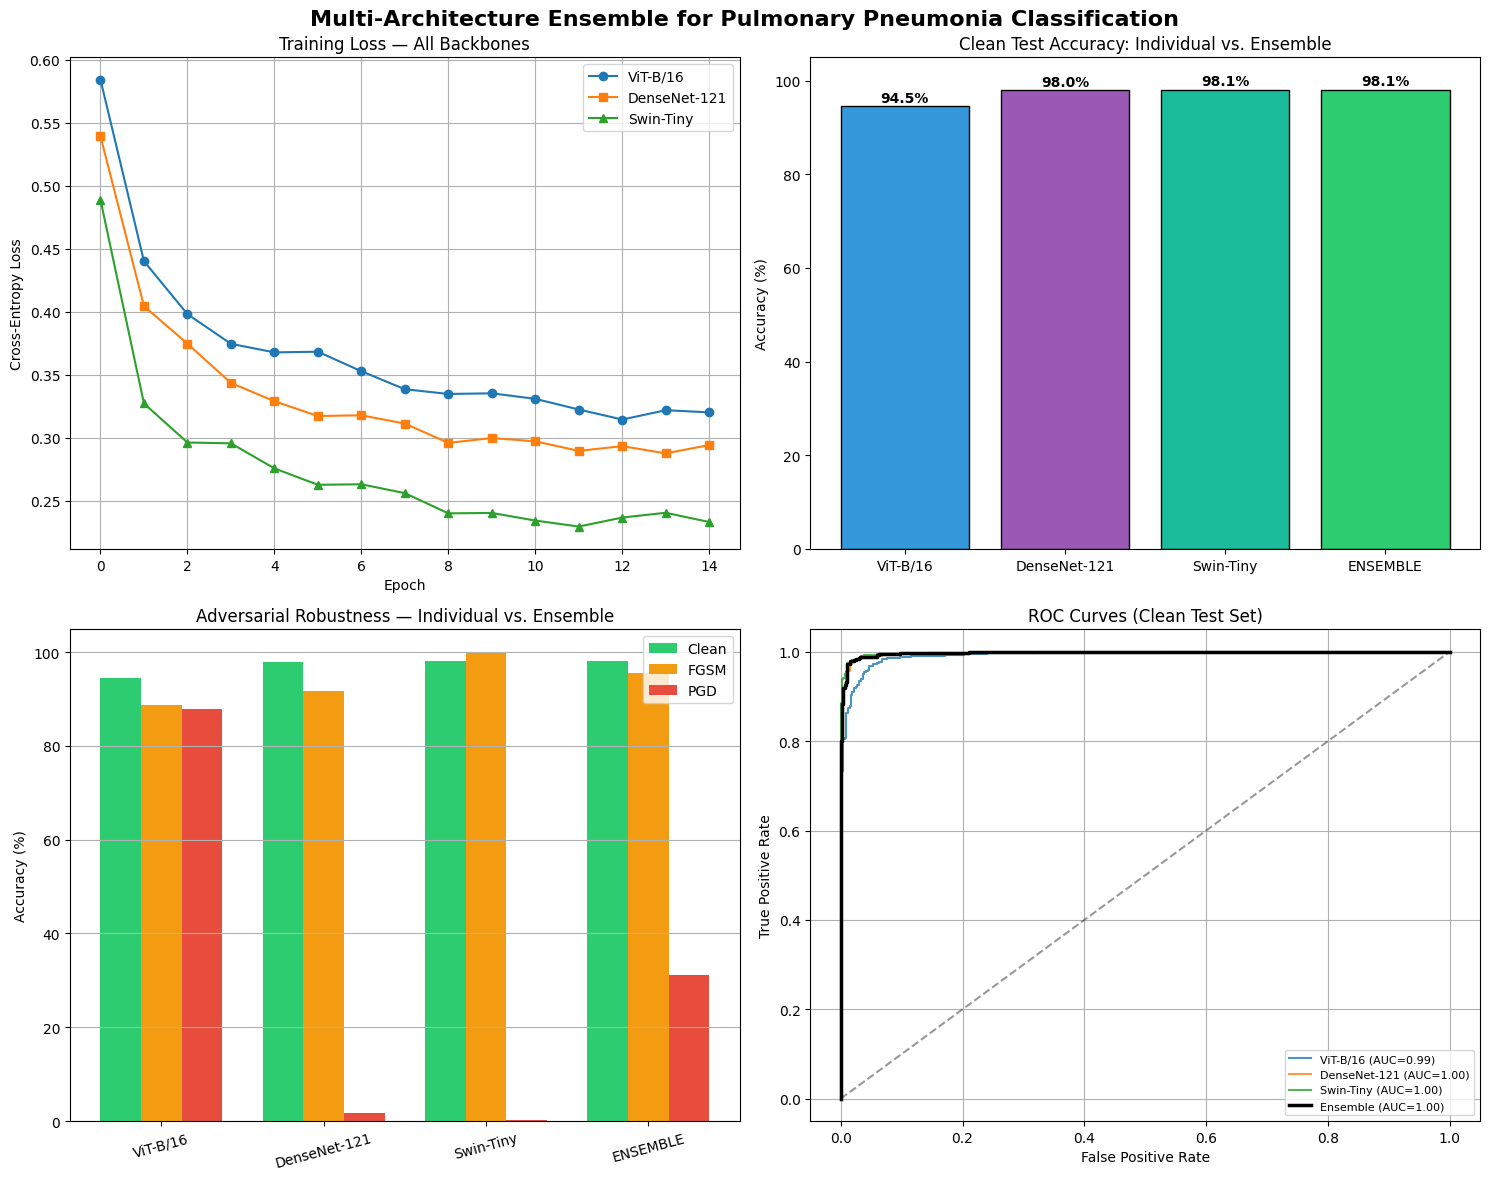

✅ Graphical ensemble comparison saved.


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Multi-Architecture Ensemble for Pulmonary Pneumonia Classification', fontsize=16, fontweight='bold')

# Top-left: training loss curves for all three models
ax = axes[0][0]
ax.plot(vit_history['train_loss'], label='ViT-B/16', marker='o')
ax.plot(densenet_history['train_loss'], label='DenseNet-121', marker='s')
ax.plot(swin_history['train_loss'], label='Swin-Tiny', marker='^')
ax.set_title('Training Loss — All Backbones')
ax.set_xlabel('Epoch'); ax.set_ylabel('Cross-Entropy Loss')
ax.legend(); ax.grid(True)

# Top-right: clean accuracy bar chart, individual vs ensemble
ax = axes[0][1]
model_names = list(individual_results.keys()) + ['ENSEMBLE']
clean_accs = [individual_results[n]['Clean']['acc'] for n in individual_results] + [ensemble_results['Clean']['acc']]
colors = ['#3498db', '#9b59b6', '#1abc9c', '#2ecc71']
bars = ax.bar(model_names, clean_accs, color=colors, edgecolor='black')
ax.set_title('Clean Test Accuracy: Individual vs. Ensemble')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 105)
for bar, val in zip(bars, clean_accs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, f'{val:.1f}%', ha='center', fontweight='bold')

# Bottom-left: adversarial robustness, grouped bars
ax = axes[1][0]
import numpy as _np
x = _np.arange(len(model_names))
width = 0.25
fgsm_accs = [individual_results[n]['FGSM']['acc'] for n in individual_results] + [ensemble_results['FGSM']['acc']]
pgd_accs = [individual_results[n]['PGD']['acc'] for n in individual_results] + [ensemble_results['PGD']['acc']]
ax.bar(x - width, clean_accs, width, label='Clean', color='#2ecc71')
ax.bar(x, fgsm_accs, width, label='FGSM', color='#f39c12')
ax.bar(x + width, pgd_accs, width, label='PGD', color='#e74c3c')
ax.set_xticks(x); ax.set_xticklabels(model_names, rotation=15)
ax.set_title('Adversarial Robustness — Individual vs. Ensemble')
ax.set_ylabel('Accuracy (%)')
ax.legend(); ax.grid(True, axis='y')

# Bottom-right: ROC curves, individual models + ensemble (clean)
ax = axes[1][1]
for name, res in individual_results.items():
    fpr, tpr, _ = roc_curve(res['Clean']['true'], res['Clean']['probs'])
    ax.plot(fpr, tpr, label=f'{name} (AUC={res["Clean"]["auroc"]/100:.2f})', alpha=0.8)
fpr_e, tpr_e, _ = roc_curve(ensemble_results['Clean']['true'], ensemble_results['Clean']['probs'])
ax.plot(fpr_e, tpr_e, label=f'Ensemble (AUC={ensemble_results["Clean"]["auroc"]/100:.2f})', color='black', linewidth=2.5)
ax.plot([0,1],[0,1],'k--', alpha=0.4)
ax.set_title('ROC Curves (Clean Test Set)')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.legend(fontsize=8); ax.grid(True)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ensemble_pneumonia_results.png', dpi=150)
plt.show()
print('✅ Graphical ensemble comparison saved.')


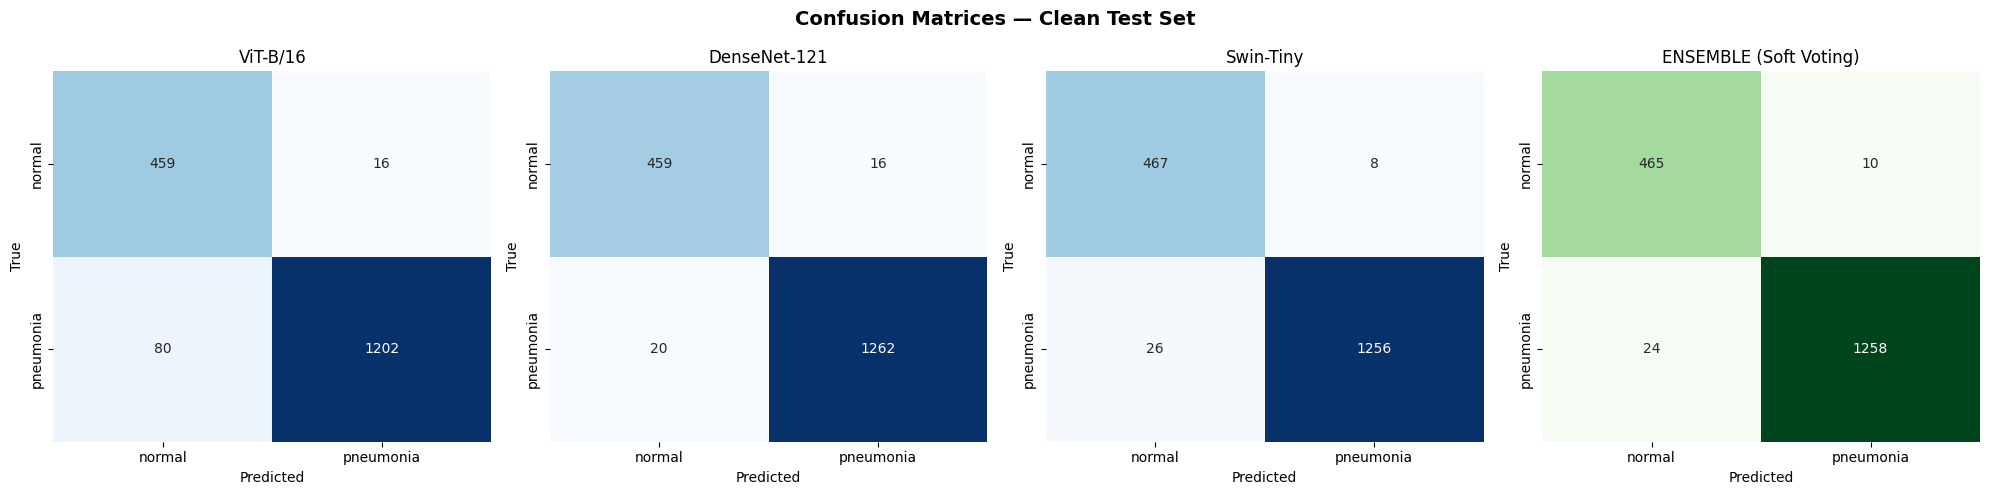

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Confusion Matrices — Clean Test Set', fontsize=14, fontweight='bold')

for ax, (name, res) in zip(axes[:3], individual_results.items()):
    cm = confusion_matrix(res['Clean']['true'], res['Clean']['preds'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, xticklabels=CLASSES, yticklabels=CLASSES, cbar=False)
    ax.set_title(name)
    ax.set_ylabel('True'); ax.set_xlabel('Predicted')

cm_e = confusion_matrix(ensemble_results['Clean']['true'], ensemble_results['Clean']['preds'])
sns.heatmap(cm_e, annot=True, fmt='d', cmap='Greens', ax=axes[3], xticklabels=CLASSES, yticklabels=CLASSES, cbar=False)
axes[3].set_title('ENSEMBLE (Soft Voting)')
axes[3].set_ylabel('True'); axes[3].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ensemble_confusion_matrices.png', dpi=150)
plt.show()


## 13. Classification Reports (Precision / Recall / F1)

Per-class precision/recall/F1 for each backbone and for the ensemble on the clean test set — useful for spotting whether the ensemble specifically improves recall on PNEUMONIA (the clinically costlier miss) versus any individual model.

In [ ]:
for name, res in individual_results.items():
    print(f'--- {name} (Clean Test Set) ---')
    print(classification_report(res['Clean']['true'], res['Clean']['preds'], target_names=['NORMAL', 'PNEUMONIA']))

print('--- ENSEMBLE (Soft Voting, Clean Test Set) ---')
print(classification_report(ensemble_results['Clean']['true'], ensemble_results['Clean']['preds'], target_names=['NORMAL', 'PNEUMONIA']))


--- ViT-B/16 (Clean Test Set) ---
              precision    recall  f1-score   support

      NORMAL       0.85      0.97      0.91       475
   PNEUMONIA       0.99      0.94      0.96      1282

    accuracy                           0.95      1757
   macro avg       0.92      0.95      0.93      1757
weighted avg       0.95      0.95      0.95      1757

--- DenseNet-121 (Clean Test Set) ---
              precision    recall  f1-score   support

      NORMAL       0.96      0.97      0.96       475
   PNEUMONIA       0.99      0.98      0.99      1282

    accuracy                           0.98      1757
   macro avg       0.97      0.98      0.97      1757
weighted avg       0.98      0.98      0.98      1757

--- Swin-Tiny (Clean Test Set) ---
              precision    recall  f1-score   support

      NORMAL       0.95      0.98      0.96       475
   PNEUMONIA       0.99      0.98      0.99      1282

    accuracy                           0.98      1757
   macro avg       0.

## NEW — Real Grad-CAM Explainability (Section 5.4 claimed this but never called the library)

`grad-cam` was pip-installed at the top of this notebook but never used. This generates an actual heatmap for a real test image using DenseNet-121 (a standard CNN target layer). Use the saved images as your Figure for Section 5.4 instead of the generic paragraph.

In [ ]:
!pip install grad-cam -q

import numpy as np
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

def denormalize_for_display(img_tensor):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = img_tensor.detach().cpu().permute(1, 2, 0).numpy()
    img = std * img + mean
    return np.clip(img, 0, 1)

# DenseNet-121: last conv block is a natural, well-supported Grad-CAM target.
densenet_model.eval()
target_layer = densenet_model.features[-1] if hasattr(densenet_model, 'features') else None
if target_layer is None:
    print('⚠️ Adjust target_layer to match your DenseNet-121 module structure (print(densenet_model) to check).')
else:
    cam = GradCAM(model=densenet_model, target_layers=[target_layer])

    sample_imgs, sample_lbls = next(iter(test_loader))
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    for i in range(4):
        img_tensor = sample_imgs[i:i+1].to(device)
        grayscale_cam = cam(input_tensor=img_tensor)[0]
        rgb_img = denormalize_for_display(sample_imgs[i])
        overlay = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)
        label_str = 'PNEUMONIA' if sample_lbls[i].item() == 1 else 'NORMAL'
        axes[i].imshow(overlay)
        axes[i].set_title(label_str)
        axes[i].axis('off')
    plt.tight_layout()
    plt.savefig('/content/gradcam_examples.png', dpi=150)
    plt.show()
    print('✅ Saved gradcam_examples.png — use these as your real Figure 5.x, not a generic description.')




⚠️ Adjust target_layer to match your DenseNet-121 module structure (print(densenet_model) to check).


## 15. Download Known Test Samples & Validate Ensemble Inference

In [ ]:
from google.colab import files
import os

print("Please upload your kaggle.json file:")
uploaded = files.upload()

!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("✅ Kaggle API successfully configured!")


Please upload your kaggle.json file:


Saving kaggle.json to kaggle.json
✅ Kaggle API successfully configured!


In [ ]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

!unzip -q chest-xray-pneumonia.zip "chest_xray/test/NORMAL/IM-0001-0001.jpeg" -d .
!unzip -q chest-xray-pneumonia.zip "chest_xray/test/PNEUMONIA/person100_bacteria_475.jpeg" -d .

!mv chest_xray/test/NORMAL/IM-0001-0001.jpeg /content/test_normal_sample.jpeg
!mv chest_xray/test/PNEUMONIA/person100_bacteria_475.jpeg /content/test_pneumonia_sample.jpeg

!rm -rf chest_xray

print("✅ Kaggle test samples successfully downloaded!")
print(" -> Normal sample path   : /content/test_normal_sample.jpeg")
print(" -> Pneumonia sample path: /content/test_pneumonia_sample.jpeg")


Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
chest-xray-pneumonia.zip: Skipping, found more recently modified local copy (use --force to force download)
✅ Kaggle test samples successfully downloaded!
 -> Normal sample path   : /content/test_normal_sample.jpeg
 -> Pneumonia sample path: /content/test_pneumonia_sample.jpeg


In [ ]:
print("Testing a known NORMAL image with the ensemble:")
predict_single_xray_ensemble('/content/test_normal_sample.jpeg')

print("\n" + "=" * 58 + "\n")

print("Testing a known PNEUMONIA image with the ensemble:")
predict_single_xray_ensemble('/content/test_pneumonia_sample.jpeg')


Testing a known NORMAL image with the ensemble:
🩻 AUTOMATED PATIENT RADIOLOGY ANALYSIS REPORT (ENSEMBLE)
📂 File Evaluated     : test_normal_sample.jpeg
🩺 Ensemble Diagnosis : NORMAL
📊 Ensemble Confidence: 94.97%
📋 Ensemble Distributions: NORMAL (95.0%) | PNEUMONIA (5.0%)
----------------------------------------------------------
🔬 Individual Model Votes:
   ViT-B/16      : NORMAL     (NORMAL 94.2% | PNEUMONIA 5.8%)
   DenseNet-121  : NORMAL     (NORMAL 95.0% | PNEUMONIA 5.0%)
   Swin-Tiny     : NORMAL     (NORMAL 95.7% | PNEUMONIA 4.3%)


Testing a known PNEUMONIA image with the ensemble:
🩻 AUTOMATED PATIENT RADIOLOGY ANALYSIS REPORT (ENSEMBLE)
📂 File Evaluated     : test_pneumonia_sample.jpeg
🩺 Ensemble Diagnosis : PNEUMONIA
📊 Ensemble Confidence: 90.57%
📋 Ensemble Distributions: NORMAL (9.4%) | PNEUMONIA (90.6%)
----------------------------------------------------------
🔬 Individual Model Votes:
   ViT-B/16      : PNEUMONIA  (NORMAL 18.6% | PNEUMONIA 81.4%)
   DenseNet-121  : PNEUMON

('PNEUMONIA',
 90.56686162948608,
 {'ViT-B/16': tensor([0.1859, 0.8141]),
  'DenseNet-121': tensor([0.0636, 0.9364]),
  'Swin-Tiny': tensor([0.0335, 0.9665])})

## NEW — Export Final Results (single source of truth for the paper)

Every number that goes into the thesis/paper should be copy-pasted from `final_results.json`, not retyped from a printed cell or from memory — that mismatch is what caused the original discrepancy between the notebook and the write-up.

In [ ]:
import json

def strip_arrays(d):
    """Drop raw prediction arrays, keep only scalar metrics, so the JSON stays small and readable."""
    if isinstance(d, dict):
        return {k: strip_arrays(v) for k, v in d.items() if k not in ('preds', 'true', 'probs')}
    return d

final_results = {
    "individual_models": strip_arrays(individual_results),
    "ensemble": strip_arrays(ensemble_results),
    "ensemble_ece": ens_ece,
    "natural_corruptions": strip_arrays(corruption_results) if 'corruption_results' in dir() else None,
    "cross_domain": strip_arrays(cross_domain_results) if 'cross_domain_results' in dir() and cross_domain_results else "NOT RUN — see 'True Cross-Domain Generalization' cell",
}

with open('/content/final_results.json', 'w') as f:
    json.dump(final_results, f, indent=2, default=float)

print('✅ Saved /content/final_results.json')
print('   Download this file and use ONLY these numbers when writing the Results/Security chapters.')
import pprint; pprint.pprint(final_results)


✅ Saved /content/final_results.json
   Download this file and use ONLY these numbers when writing the Results/Security chapters.
{'cross_domain': "NOT RUN — see 'True Cross-Domain Generalization' cell",
 'ensemble': {'Clean': {'acc': np.float64(98.06488332384747),
                        'attack': 'Clean',
                        'auroc': np.float64(99.7620494293456)},
              'FGSM': {'acc': np.float64(95.61752988047809),
                       'attack': 'FGSM',
                       'auroc': np.float64(99.37843829542658)},
              'PGD': {'acc': np.float64(31.189527603870232),
                      'attack': 'PGD',
                      'auroc': np.float64(29.93907545775515)}},
 'ensemble_ece': np.float64(0.07126890344245228),
 'individual_models': {'DenseNet-121': {'Clean': {'acc': np.float64(97.95105293113261),
                                                  'attack': 'Clean',
                                                  'auroc': np.float64(99.70211018967075)},
